# DS4400 Homework 3 -- Isabella Caruz

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve, 
    auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

In [33]:
columns = [
"word_freq_make",
"word_freq_address",
"word_freq_all",
"word_freq_3d",
"word_freq_our",
"word_freq_over",
"word_freq_remove",
"word_freq_internet",
"word_freq_order",
"word_freq_mail",
"word_freq_receive",
"word_freq_will",
"word_freq_people",
"word_freq_report",
"word_freq_addresses",
"word_freq_free",
"word_freq_business",
"word_freq_email",
"word_freq_you",
"word_freq_credit",
"word_freq_your",
"word_freq_font",
"word_freq_000",
"word_freq_money",
"word_freq_hp",
"word_freq_hpl",
"word_freq_george",
"word_freq_650",
"word_freq_lab",
"word_freq_labs",
"word_freq_telnet",
"word_freq_857",
"word_freq_data",
"word_freq_415",
"word_freq_85",
"word_freq_technology",
"word_freq_1999",
"word_freq_parts",
"word_freq_pm",
"word_freq_direct",
"word_freq_cs",
"word_freq_meeting",
"word_freq_original",
"word_freq_project",
"word_freq_re",
"word_freq_edu",
"word_freq_table",
"word_freq_conference",
"char_freq_;",
"char_freq_(",
"char_freq_[",
"char_freq_!",
"char_freq_$",
"char_freq_#",
"capital_run_length_average",
"capital_run_length_longest",
"capital_run_length_total",
"spam"
]

data = pd.read_csv("spambase.data", header=None, names=columns)
data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


## [C] Problem 1: Logistic regression (25 points)

In [9]:
X = data.drop("spam", axis=1)
y = data["spam"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", round(accuracy,4))
print("Error:", round(error,4))
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1 Score:", round(f1,4))

Confusion Matrix:
 [[651  25]
 [ 55 420]]
Accuracy: 0.9305
Error: 0.0695
Precision: 0.9438
Recall: 0.8842
F1 Score: 0.913


In [13]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="coefficient", ascending=False)

print("Top positive features:")
print(coefficients.head(10))

print("Top negative features:")
print(coefficients.tail(10))

Top positive features:
                 feature  coefficient
52           char_freq_$     3.524484
22         word_freq_000     2.124704
6       word_freq_remove     2.120883
14   word_freq_addresses     1.465750
53           char_freq_#     1.113235
15        word_freq_free     1.015338
35  word_freq_technology     0.943894
19      word_freq_credit     0.922501
16    word_freq_business     0.898894
3           word_freq_3d     0.749603
Top negative features:
                 feature  coefficient
48           char_freq_;    -1.005676
32        word_freq_data    -1.171728
28         word_freq_lab    -1.173245
40          word_freq_cs    -1.253627
45         word_freq_edu    -1.372877
41     word_freq_meeting    -1.540766
47  word_freq_conference    -1.742566
43     word_freq_project    -1.773425
24          word_freq_hp    -1.820135
26      word_freq_george    -4.332132


In [14]:
probs = model.predict_proba(X_test)[:,1]

thresholds = [0.25,0.5,0.75,0.9]

for t in thresholds:

    preds = (probs >= t).astype(int)

    acc = accuracy_score(y_test,preds)
    prec = precision_score(y_test,preds)
    rec = recall_score(y_test,preds)

    print("Threshold:", t)
    print("Accuracy:", round(acc,3))
    print("Precision:", round(prec,3))
    print("Recall:", round(rec,3))

Threshold: 0.25
Accuracy: 0.909
Precision: 0.841
Recall: 0.96
Threshold: 0.5
Accuracy: 0.93
Precision: 0.944
Recall: 0.884
Threshold: 0.75
Accuracy: 0.888
Precision: 0.958
Recall: 0.762
Threshold: 0.9
Accuracy: 0.823
Precision: 0.972
Recall: 0.587


## [C] Problem 2: Gradient Descent for Logistic regression (25 points)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_np = X_train_scaled
X_test_np = X_test_scaled

y_train_np = y_train
y_test_np = y_test

X_train_gd = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]
X_test_gd = np.c_[np.ones((X_test_np.shape[0], 1)), X_test_np]


In [27]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy(y_true, y_prob):
    eps = 1e-10
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

In [28]:
alphas = [0.001, 0.01, 0.1]
iters_list = [10, 50, 100]

rows = []

for a in alphas:
    for it in iters_list:
        theta = np.zeros(X_train_gd.shape[1])

        for _ in range(it):
            preds = sigmoid(X_train_gd @ theta)
            grad = (1 / len(y_train_np)) * (X_train_gd.T @ (preds - y_train_np))
            theta = theta - a * grad

        train_probs = sigmoid(X_train_gd @ theta)
        test_probs = sigmoid(X_test_gd @ theta)

        train_pred = (train_probs >= 0.5).astype(int)
        test_pred = (test_probs >= 0.5).astype(int)

        rows.append({
            "learning_rate": a,
            "iterations": it,
            "train_loss": cross_entropy(y_train_np, train_probs),
            "test_loss": cross_entropy(y_test_np, test_probs),
            "train_accuracy": accuracy_score(y_train_np, train_pred),
            "test_accuracy": accuracy_score(y_test_np, test_pred),
            "test_precision": precision_score(y_test_np, test_pred),
            "test_recall": recall_score(y_test_np, test_pred),
            "test_f1": f1_score(y_test_np, test_pred)
        })

gd_results = pd.DataFrame(rows)
print(gd_results)

   learning_rate  iterations  train_loss  test_loss  train_accuracy  \
0          0.001          10    0.688583   0.688396        0.895942   
1          0.001          50    0.671212   0.670357        0.896232   
2          0.001         100    0.651333   0.649798        0.895942   
3          0.010          10    0.651167   0.649621        0.895942   
4          0.010          50    0.541620   0.537475        0.896812   
5          0.010         100    0.468734   0.463341        0.897681   
6          0.100          10    0.465377   0.459840        0.897681   
7          0.100          50    0.324124   0.314600        0.904928   
8          0.100         100    0.289078   0.277023        0.907826   

   test_accuracy  test_precision  test_recall   test_f1  
0       0.899218        0.879493     0.875789  0.877637  
1       0.899218        0.881104     0.873684  0.877378  
2       0.899218        0.881104     0.873684  0.877378  
3       0.899218        0.881104     0.873684  0.877378  

In [29]:
loss_table = gd_results.pivot(
    index="learning_rate",
    columns="iterations",
    values="train_loss"
)

print(loss_table.round(6))

iterations          10        50        100
learning_rate                              
0.001          0.688583  0.671212  0.651333
0.010          0.651167  0.541620  0.468734
0.100          0.465377  0.324124  0.289078


In [30]:
metrics_100 = gd_results[gd_results["iterations"] == 100][[
    "learning_rate", "train_accuracy", "test_accuracy",
    "test_precision", "test_recall", "test_f1"
]]

print(metrics_100.round(6))

   learning_rate  train_accuracy  test_accuracy  test_precision  test_recall  \
2          0.001        0.895942       0.899218        0.881104     0.873684   
5          0.010        0.897681       0.903562        0.900881     0.861053   
8          0.100        0.907826       0.906169        0.923788     0.842105   

    test_f1  
2  0.877378  
5  0.880517  
8  0.881057  


In [ ]:
package_model = LogisticRegression(max_iter=5000)
package_model.fit(X_train_scaled, y_train)

pkg_train_pred = package_model.predict(X_train_scaled)
pkg_test_pred = package_model.predict(X_test_scaled)

print("Package model training metrics:")
print("Accuracy:", accuracy_score(y_train, pkg_train_pred))
print("Precision:", precision_score(y_train, pkg_train_pred))
print("Recall:", recall_score(y_train, pkg_train_pred))
print("F1:", f1_score(y_train, pkg_train_pred))

print("Package model testing metrics:")
print("Accuracy:", accuracy_score(y_test, pkg_test_pred))
print("Precision:", precision_score(y_test, pkg_test_pred))
print("Recall:", recall_score(y_test, pkg_test_pred))
print("F1:", f1_score(y_test, pkg_test_pred))

Package model training metrics:
Accuracy: 0.9257971014492754
Precision: 0.9239811912225705
Recall: 0.8811659192825112
F1: 0.9020657995409334

Package model testing metrics:
Accuracy: 0.9226759339704604
Precision: 0.9386363636363636
Recall: 0.8694736842105263
F1: 0.9027322404371585


## [C] Problem 3: Comparing classifiers (25 points)

In [34]:
k_values = [1,3,5,7,9,11,15,21]

rows = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    # cross-validation predictions
    preds = cross_val_predict(knn, X_train_scaled, y_train, cv=5)

    acc = accuracy_score(y_train, preds)
    err = 1 - acc
    prec = precision_score(y_train, preds)
    rec = recall_score(y_train, preds)

    rows.append({
        "k": k,
        "accuracy": acc,
        "error": err,
        "precision": prec,
        "recall": rec
    })

cv_results = pd.DataFrame(rows)

print(cv_results.sort_values("k"))

    k  accuracy     error  precision    recall
0   1  0.901449  0.098551   0.877458  0.866966
1   3  0.900870  0.099130   0.881902  0.859492
2   5  0.902609  0.097391   0.890187  0.854260
3   7  0.906667  0.093333   0.895639  0.859492
4   9  0.904928  0.095072   0.898894  0.850523
5  11  0.900580  0.099420   0.897047  0.840060
6  15  0.898841  0.101159   0.901054  0.830344
7  21  0.890725  0.109275   0.899418  0.808670


In [35]:
best_k = cv_results.loc[cv_results["error"].idxmin(), "k"]
print("Best k:", best_k)

Best k: 7


In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN (k=7)": KNeighborsClassifier(n_neighbors=7)
}

rows = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Train Error": 1 - accuracy_score(y_train, train_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Train Recall": recall_score(y_train, train_pred),

        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Error": 1 - accuracy_score(y_test, test_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Test Recall": recall_score(y_test, test_pred)
    })

comparison = pd.DataFrame(rows)

print(comparison)

                 Model  Train Accuracy  Train Error  Train Precision  \
0  Logistic Regression        0.925797     0.074203         0.923981   
1                  LDA        0.886667     0.113333         0.915716   
2            kNN (k=7)        0.922609     0.077391         0.916732   

   Train Recall  Test Accuracy  Test Error  Test Precision  Test Recall  
0      0.881166       0.922676    0.077324        0.938636     0.869474  
1      0.779522       0.885317    0.114683        0.929825     0.781053  
2      0.880419       0.901825    0.098175        0.911364     0.844211  


AUC: 0.9748894425412644


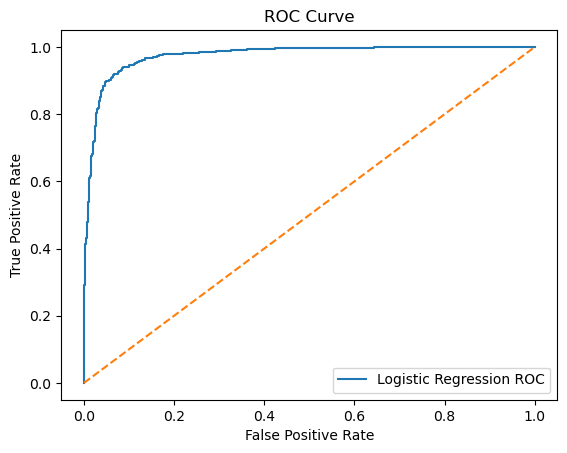

In [47]:
probs = package_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression ROC")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

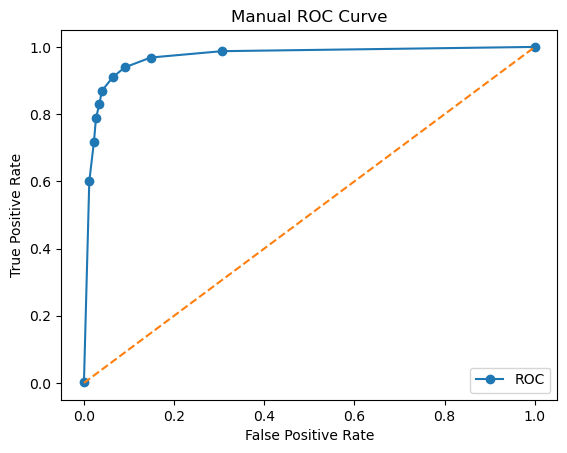

In [46]:
thresholds = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

fpr_list = []
tpr_list = []

probs = package_model.predict_proba(X_test_scaled)[:,1]

for t in thresholds:

    preds = (probs >= t).astype(int)

    TP = ((preds == 1) & (y_test == 1)).sum()
    FP = ((preds == 1) & (y_test == 0)).sum()
    TN = ((preds == 0) & (y_test == 0)).sum()
    FN = ((preds == 0) & (y_test == 1)).sum()

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    tpr_list.append(TPR)
    fpr_list.append(FPR)

plt.figure()
plt.plot(fpr_list, tpr_list, marker="o", label="ROC")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve")
plt.legend()
plt.show()

## [C] Problem 4: Cross validation (25 points)

In [49]:
X = X_train_scaled
y = y_train

def k_fold_cv(model, X, y, k):

    n = len(X)
    fold_size = n // k
    errors = []

    for i in range(k):

        start = i * fold_size
        end = start + fold_size

        X_val = X[start:end]
        y_val = y[start:end]

        X_train_cv = np.concatenate((X[:start], X[end:]), axis=0)
        y_train_cv = np.concatenate((y[:start], y[end:]), axis=0)

        model.fit(X_train_cv, y_train_cv)

        preds = model.predict(X_val)

        acc = accuracy_score(y_val, preds)
        err = 1 - acc

        errors.append(err)

    avg_error = np.mean(errors)

    return avg_error

k_values = [5,10]

for k in k_values:

    log_model = LogisticRegression(max_iter=5000)
    lda_model = LinearDiscriminantAnalysis()

    log_error = k_fold_cv(log_model, X, y, k)
    lda_error = k_fold_cv(lda_model, X, y, k)

    print("k =", k)
    print("Logistic Regression Avg Validation Error:", log_error)
    print("LDA Avg Validation Error:", lda_error)
    print()

k = 5
Logistic Regression Avg Validation Error: 0.07884057971014491
LDA Avg Validation Error: 0.11565217391304347

k = 10
Logistic Regression Avg Validation Error: 0.07768115942028987
LDA Avg Validation Error: 0.11478260869565218

